In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
from matplotlib.colors import LogNorm, Normalize, ListedColormap
from matplotlib.patches import Patch
from skimage import measure
from scipy import stats

In [ ]:
RESULTS = "/home/users/annaju/results/wc_les_RICO_40m_80kmx80km_T_qc_30.0h"
cot_true      = xr.open_dataset(f"{RESULTS}/reconstructed_scene_cot_trueCOT.nc")
metrics_true = pd.read_csv(f"{RESULTS}/cloud_metrics_trueCOT.csv")
cot_pred      = xr.open_dataset(f"{RESULTS}/reconstructed_scene_cot_predCOT.nc")
metrics_pred = pd.read_csv(f"{RESULTS}/cloud_metrics_predCOT.csv")

In [4]:
df_true = pd.read_parquet(f"{RESULTS}/cloud_voxels_trueCOT.parquet")
df_true["bias"] = df_true.rec_ext - df_true.true_ext
df_true["absolute_error"] = np.abs(df_true.bias)

df_pred = pd.read_parquet(f"{RESULTS}/cloud_voxels_predCOT.parquet")
df_pred["bias"] = df_pred.rec_ext - df_pred.true_ext
df_pred["absolute_error"] = np.abs(df_pred.bias)

### Prediction Visualizations

In [6]:
df_pred.head()

,cloud_id,true_ext,rec_ext,height_km,com_km,width_x_km,width_y_km,bias,absolute_error
0,857,0.000124,13.958624,2.0,1.38,5.16,2.88,13.958500,13.958500
1,857,0.000684,12.431711,2.0,1.38,5.16,2.88,12.431027,12.431027
2,857,0.000088,10.543084,2.0,1.38,5.16,2.88,10.542995,10.542995
3,857,0.000001,0.000000,2.0,1.38,5.16,2.88,-0.000001,0.000001
4,857,0.000039,0.000000,2.0,1.38,5.16,2.88,-0.000039,0.000039


In [117]:
len(df_pred['cloud_id'].unique()), len(df_pred)

(6344, 3325139)

#### Scatter Plots

In [ ]:
def scatter_density(x, y, x_name, y_name, title, save_dir=None, n_sample=5000):
    '''
    makes a scatter plot and color codes where most of the data is
    :param x: x-value
    :param y: y-value
    :param x_name: name on x-axis
    :param y_name: name on y-axis
    :param title: title
    :param save_dir: save location
    :return: -
    '''
    # print('making scatter density plot ... ')
    # need to reduce number of samples to keep processing time reasonable.
    # Reduce if processing time too long or run out of RAM
    #max_n = 50000
    if n_sample > len(x):
        n_sample = len(x)
    #subsample = int(len(x) / max_n)
    rand_idx = np.random.choice(len(x), n_sample, replace=False)
    x = x[rand_idx] #random.sample(x, n_sample)#x[::subsample]
    y = y[rand_idx] #random.sample(y, n_sample)#y[::subsample]
    try:
        r, _ = stats.pearsonr(x, y)  # get R
    except:
        print('could not calculate r, set to nan')
        r = np.nan
    xy = np.vstack([x, y])
    if np.mean(x) == np.mean(y):
        z = np.arange(len(x))
    else:
        z = stats.gaussian_kde(xy)(xy)  # calculate density
    # sort points by density
    idx = z.argsort()
    d_feature = x[idx]
    d_target = y[idx]
    z = z[idx]
    # plot everything
    fig = plt.figure(figsize=(5.2,5), dpi=120, constrained_layout=True)
    ax = fig.add_subplot(111)
    ax.grid(ls=":", zorder=-100)
    ax.scatter(d_feature, d_target, c=z, s=0.3, label='R = ' + str(np.round(r, 2)), zorder=100)
    vmin = np.min([np.percentile(d_feature,1), np.percentile(d_target,1)])
    vmax = np.max([np.percentile(d_feature,99), np.percentile(d_target,99)])
    ax.set_xlim(vmin, vmax)
    ax.set_ylim(vmin, vmax)
    ax.plot([vmin,vmax],[vmin,vmax], '0.8', ls="--", zorder=200, linewidth=3, label="1:1 line", color="grey")
    # linear fit
    slope, offset = np.polyfit(x,y, 1)
    ax.plot([vmin, vmax], [vmin*slope+offset, vmax*slope+offset], "r--", linewidth=3, label=f"linear fit: {slope:.2f}x + {offset:.2f}", zorder=200)
    # ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    leg = ax.legend(facecolor="white", framealpha=1, edgecolor="0.8", loc='lower right')
    leg.set_zorder(300)
    ax.set_xlabel(x_name)
    ax.set_ylabel(y_name)
    ax.set_title(title)
    #plt.tight_layout()

    if save_dir is not None:
        save_fname = os.path.join(save_dir, title.lower().replace(" ","_")+"_scatter_density.png")
        fig.savefig(save_fname)
        plt.close()

From Predictions

/tmp/ipykernel_4171438/452207139.py:49: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "0.8" (-> color=(0.8, 0.8, 0.8, 1.0)). The keyword argument will take precedence.
  ax.plot([vmin,vmax],[vmin,vmax], '0.8', ls="--", zorder=200, linewidth=3, label="1:1 line", color="grey")


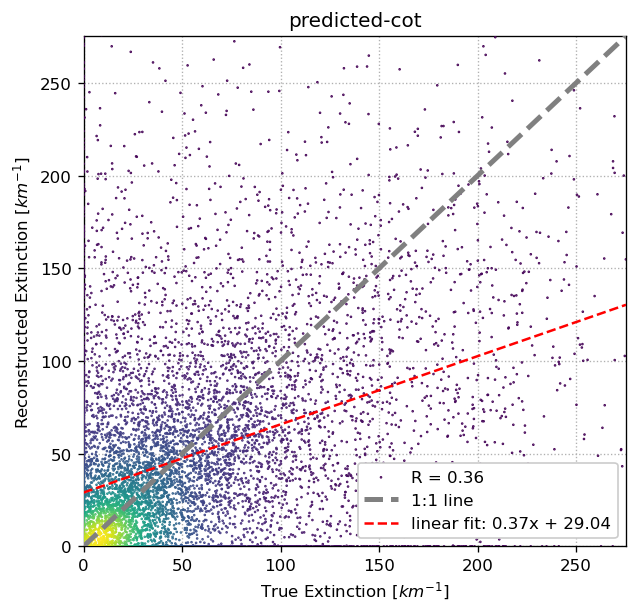

In [76]:
scatter_density(df_pred.true_ext.values, df_pred.rec_ext.values, r"True Extinction [$km^{-1}$]", r"Reconstructed Extinction [$km^{-1}$]", f"predicted-cot", n_sample=10000)

(0.0, 500.0)

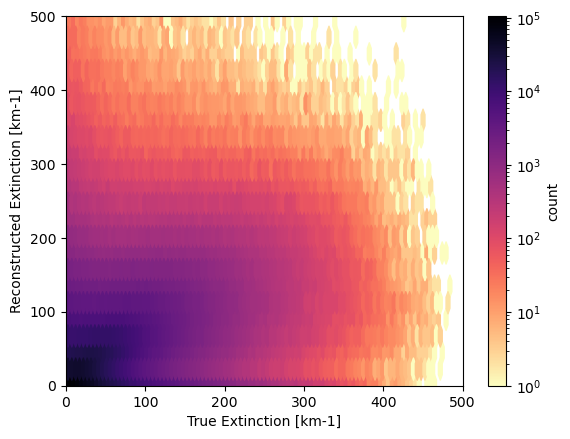

In [ ]:
# 1. predicted vs target, all voxels
plt.hexbin(df_pred.true_ext, df_pred.rec_ext, yscale="linear", xscale="linear", bins="log", mincnt=1, cmap="magma_r")
plt.colorbar(label="count")
plt.xlabel("True Extinction [km-1]")
plt.ylabel("Reconstructed Extinction [km-1]")
plt.xlim(0., 500)
# plt.ylim(0., 500)

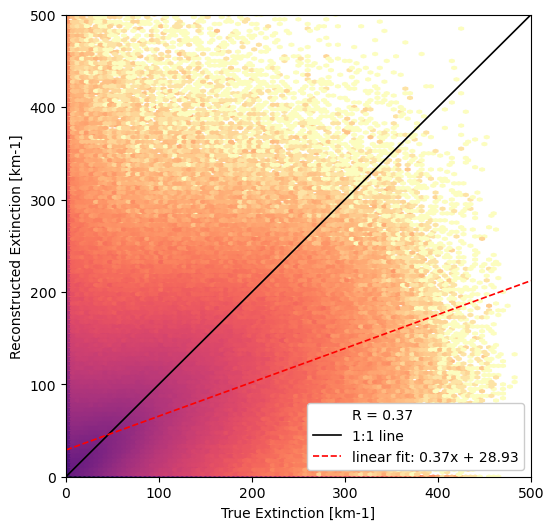

In [64]:
xlim, ylim = (0, 500), (0, 500)
# nx, ny = 70, 35

x = df_pred.true_ext.values
y = df_pred.rec_ext.values
good = np.isfinite(x) & np.isfinite(y)
x, y = x[good], y[good]

r, _ = stats.pearsonr(x, y)
slope, offset = np.polyfit(x, y, 1)

fig, ax = plt.subplots(figsize=(6, 6))
hb = ax.hexbin(x, y,
               bins="log", mincnt=1,
               gridsize=(100, 100),
               extent=(xlim[0], xlim[1], ylim[0], ylim[1]),
               cmap='magma_r')
ax.plot([], [], ' ', label=f"R = {r:.2f}")                     # text-only legend entry
ax.axline((0, 0), slope=1, color="black", ls="-", lw=1.2, label="1:1 line")
ax.plot(xlim, [xlim[0]*slope + offset, xlim[1]*slope + offset],
        "r--", lw=1.2, label=f"linear fit: {slope:.2f}x + {offset:.2f}")
ax.set_xlim(*xlim)
ax.set_ylim(*ylim)
# ax.set_box_aspect(np.sqrt(3) * ny / nx)
# plt.colorbar(hb, ax=ax, label="count")
ax.set_xlabel("True Extinction [km-1]")
ax.set_ylabel("Reconstructed Extinction [km-1]")
leg = ax.legend(facecolor="white", framealpha=1, edgecolor="0.8", loc="lower right")
leg.set_zorder(300)
plt.savefig(f"{RESULTS}/plots/predicted-cot_scatter_hexplot.png", dpi=300)


From True

(0.0, 500.0)

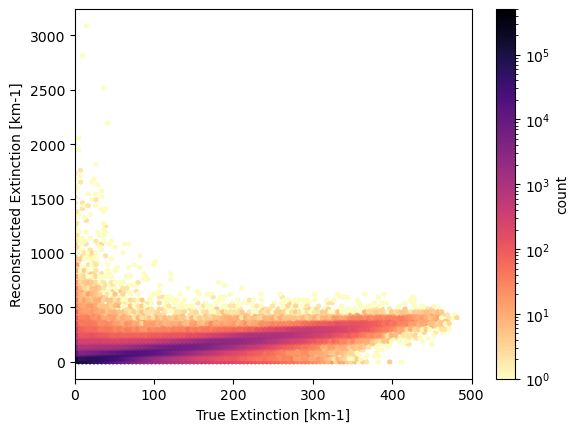

In [ ]:
# 1. predicted vs target, all voxels
plt.hexbin(df_true.true_ext, df_true.rec_ext, yscale="linear", xscale="linear", bins="log", mincnt=1, cmap="magma_r")
plt.colorbar(label="count")
plt.xlabel("True Extinction [km-1]")
plt.ylabel("Reconstructed Extinction [km-1]")
plt.xlim(0., 500)
# plt.ylim(0., 500)

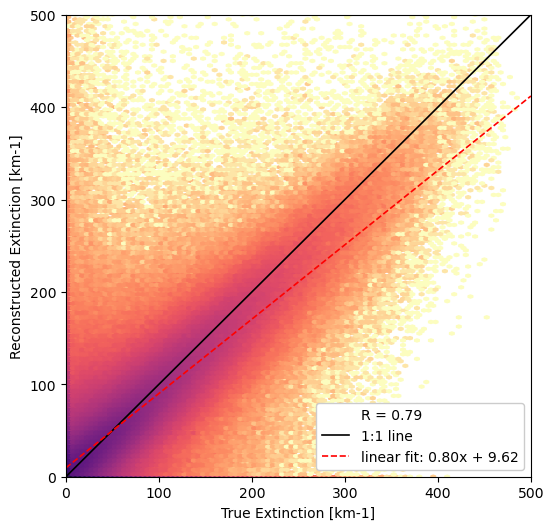

In [65]:
xlim, ylim = (0, 500), (0, 500)
# nx, ny = 70, 35

x = df_true.true_ext.values
y = df_true.rec_ext.values
good = np.isfinite(x) & np.isfinite(y)
x, y = x[good], y[good]

r, _ = stats.pearsonr(x, y)
slope, offset = np.polyfit(x, y, 1)

fig, ax = plt.subplots(figsize=(6, 6))
hb = ax.hexbin(x, y,
               bins="log", mincnt=1,
               gridsize=(100, 100),
               extent=(xlim[0], xlim[1], ylim[0], ylim[1]),
               cmap='magma_r')
ax.plot([], [], ' ', label=f"R = {r:.2f}")                     # text-only legend entry
ax.axline((0, 0), slope=1, color="black", ls="-", lw=1.2, label="1:1 line")
ax.plot(xlim, [xlim[0]*slope + offset, xlim[1]*slope + offset],
        "r--", lw=1.2, label=f"linear fit: {slope:.2f}x + {offset:.2f}")
ax.set_xlim(*xlim)
ax.set_ylim(*ylim)
# ax.set_box_aspect(np.sqrt(3) * ny / nx)
# plt.colorbar(hb, ax=ax, label="count")
ax.set_xlabel("True Extinction [km-1]")
ax.set_ylabel("Reconstructed Extinction [km-1]")
leg = ax.legend(facecolor="white", framealpha=1, edgecolor="0.8", loc="lower right")
leg.set_zorder(300)
plt.savefig(f"{RESULTS}/plots/true-cot_scatter_hexplot.png", dpi=300)


#### Error Plots

From Predictions

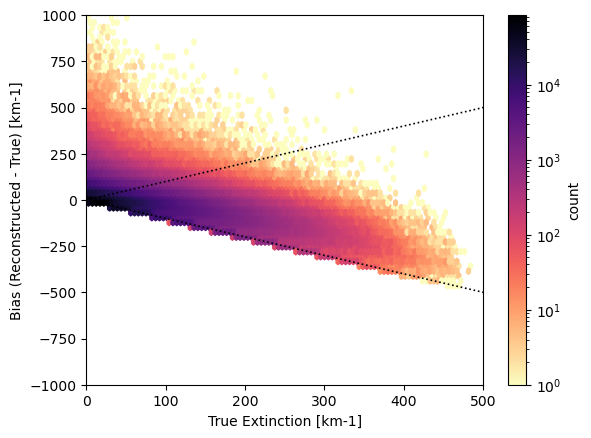

In [ ]:
# 2. error vs true extinction
plt.hexbin(df_pred.true_ext, df_pred.bias, xscale="linear", bins="log", mincnt=1, cmap="magma_r")
plt.colorbar(label="count")
plt.xlabel("True Extinction [km-1]")
plt.ylabel("Bias (Reconstructed - True) [km-1]")
plt.xlim(0., 500)
plt.ylim(-1000, 1000)
plt.axline((0, 0), slope=1, color="black", ls="dotted", lw=1.2)
plt.axline((0, 0), slope=-1, color="black", ls="dotted", lw=1.2)

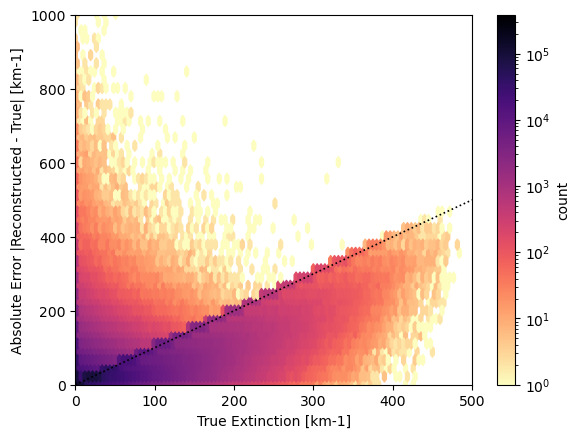

In [ ]:
# 2. error vs true extinction
plt.hexbin(df_pred.true_ext, df_pred.absolute_error, xscale="linear", bins="log", mincnt=1, cmap="magma_r")
plt.xlabel("True Extinction [km-1]")
plt.ylabel("Absolute Error |Reconstructed - True| [km-1]")
plt.colorbar(label="count")
plt.xlim(0., 500)
plt.ylim(0, 1000)
plt.axline((0, 0), slope=1, color="black", ls="dotted", lw=1.2)

From True

(-1000.0, 1000.0)

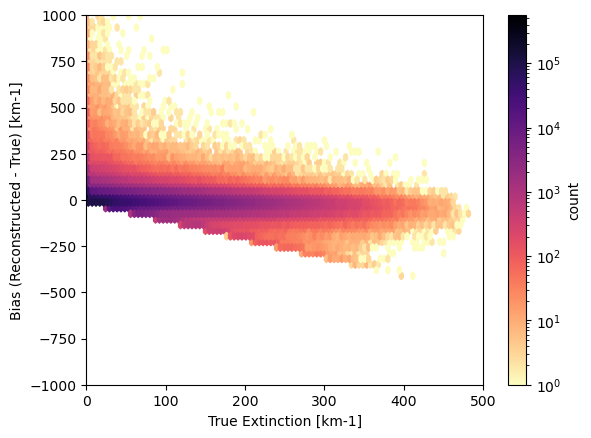

In [188]:
# 2. error vs true extinction
plt.hexbin(df_true.true_ext, df_true.bias, xscale="linear", bins="log", mincnt=1, cmap="magma_r")
plt.colorbar(label="count")
plt.xlabel("True Extinction [km-1]")
plt.ylabel("Bias (Reconstructed - True) [km-1]")
plt.xlim(0., 500)
plt.ylim(-1000, 1000)


(0.0, 500.0)

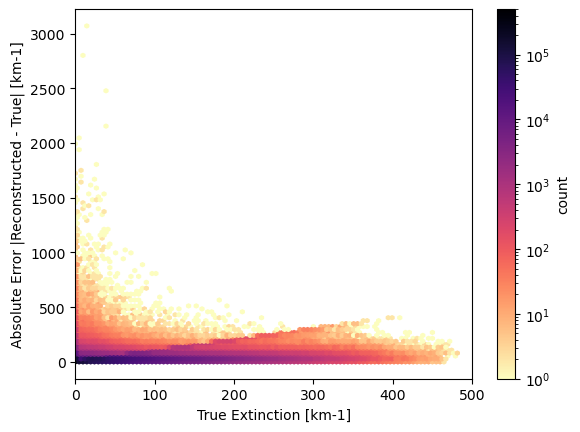

In [193]:
# 2. error vs true extinction
plt.hexbin(df_true.true_ext, df_true.absolute_error, xscale="linear", bins="log", mincnt=1, cmap="magma_r")
plt.xlabel("True Extinction [km-1]")
plt.ylabel("Absolute Error |Reconstructed - True| [km-1]")
plt.colorbar(label="count")
plt.xlim(0., 500)
# plt.ylim(0, 1000)

#### Aspect Ratio Plots

In [96]:
metrics_true.columns

Index(['cloud_id', 'status', 'error_msg', 'scene', 'mode', 'bbox_x0',
       'bbox_x1', 'bbox_y0', 'bbox_y1', 'centroid_x_km', 'centroid_y_km',
       'area_km2', 'equiv_diameter_km', 'n_columns', 'n_cloud_voxels',
       'cbh_km', 'cth_km', 'height_km', 'com_km', 'mean_true_ext',
       'std_true_ext', 'max_true_ext', 'mean_rec_ext', 'std_rec_ext', 'rmse',
       'rmse_all', 'mae', 'mae_std', 'bias', 'bias_std', 'rmse_norm', 'r',
       'cot_true_mean', 'cot_true_std', 'cot_rec_mean', 'cot_rec_std',
       'cot_nadir_mean', 'cot_nadir_std', 'cot_bias', 'cot_bias_std',
       'cot_rmse', 'niter', 'runtime_s'],
      dtype='str')

From Predictions

Text(0, 0.5, 'MAE (per cloud) [km-1]')

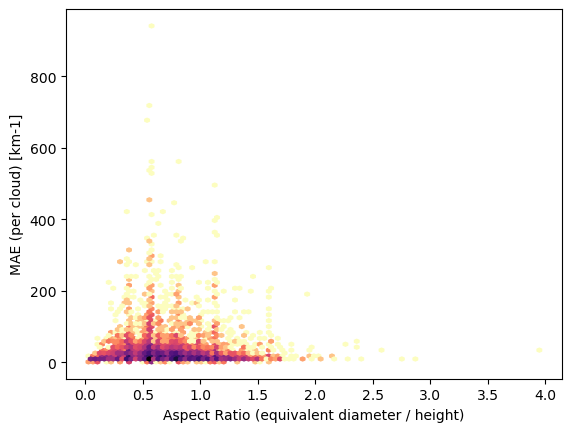

In [194]:
# 3. error vs aspect ratio - per cloud, from the CSV
aspect = (metrics_pred['equiv_diameter_km'] / metrics_pred['height_km'])
plt.hexbin(aspect, metrics_pred.mae, xscale="linear", bins="log", mincnt=1, cmap="magma_r")
plt.xlabel("Aspect Ratio (equivalent diameter / height)")
plt.ylabel("MAE (per cloud) [km-1]")

From True

Text(0, 0.5, 'MAE (per cloud) [km-1]')

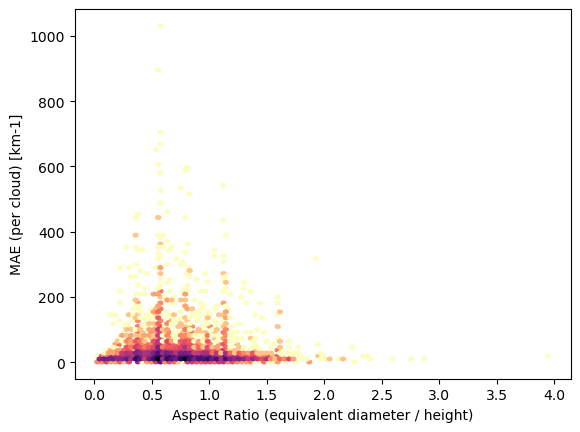

In [195]:
# 3. error vs aspect ratio - per cloud, from the CSV
aspect = (metrics_true['equiv_diameter_km'] / metrics_true['height_km'])
plt.hexbin(aspect, metrics_true.mae, xscale="linear", bins="log", mincnt=1, cmap="magma_r")
plt.xlabel("Aspect Ratio (equivalent diameter / height)")
plt.ylabel("MAE (per cloud) [km-1]")

#### Other Plots

In [212]:
metrics_pred.columns

Index(['cloud_id', 'status', 'error_msg', 'scene', 'mode', 'bbox_x0',
       'bbox_x1', 'bbox_y0', 'bbox_y1', 'centroid_x_km', 'centroid_y_km',
       'area_km2', 'equiv_diameter_km', 'n_columns', 'n_cloud_voxels',
       'cbh_km', 'cth_km', 'height_km', 'com_km', 'mean_true_ext',
       'std_true_ext', 'max_true_ext', 'mean_rec_ext', 'std_rec_ext', 'rmse',
       'rmse_all', 'mae', 'mae_std', 'bias', 'bias_std', 'rmse_norm', 'r',
       'cot_true_mean', 'cot_true_std', 'cot_rec_mean', 'cot_rec_std',
       'cot_nadir_mean', 'cot_nadir_std', 'cot_bias', 'cot_bias_std',
       'cot_rmse', 'niter', 'runtime_s'],
      dtype='str')

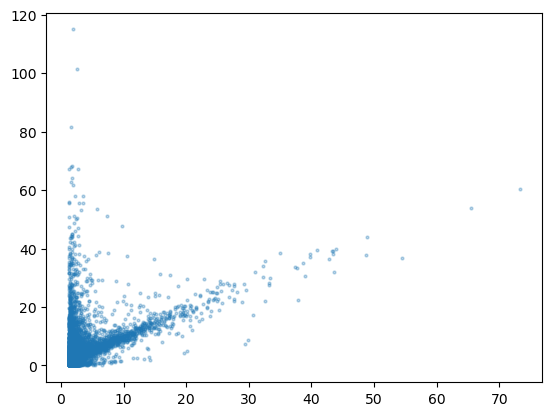

In [220]:
plt.scatter(metrics_pred['cot_true_mean'], metrics_pred['cot_rec_mean'], s=4, alpha=0.3)

(0.0, 120.0)

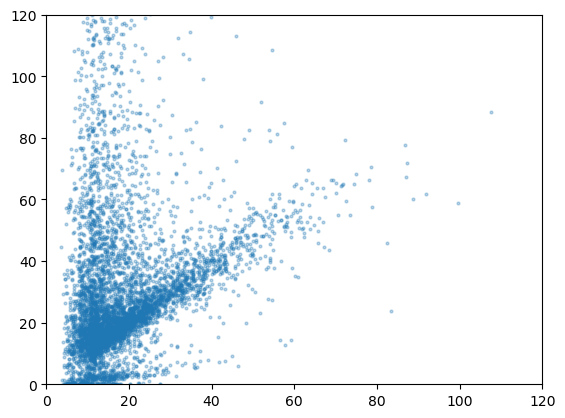

In [217]:
plt.scatter(metrics_pred['mean_true_ext'], metrics_pred['mean_rec_ext'], s=4, alpha=0.3)
plt.xlim(0, 120)
plt.ylim(0, 120)

Text(0, 0.5, 'Count')

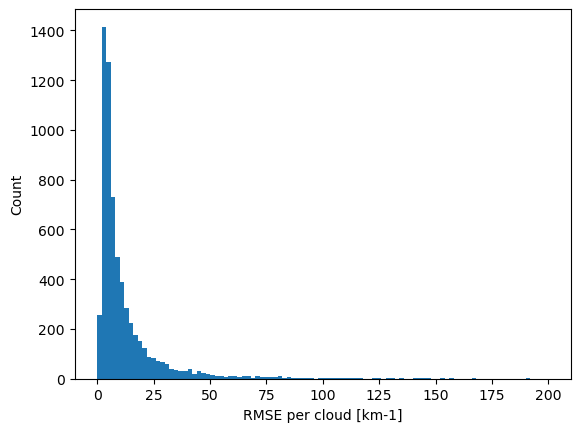

In [221]:
plt.hist(metrics_pred['rmse_all'], bins=100, range=(0, 200), density=False);
plt.xlabel("RMSE per cloud [km-1]")
plt.ylabel("Count")